In [2]:
print("Hello World")

Hello World


In [3]:

pip install kagglehub seaborn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# Import Library
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [5]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("mubashirsidiki/student-academic-performance-500-students")

print("Path to dataset files:", path)

# Construct the full path to the CSV file
file_path = os.path.join(path, "student_performance.csv")

df = pd.read_csv(file_path)

c:\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Administrator\.cache\kagglehub\datasets\mubashirsidiki\student-academic-performance-500-students\versions\4


In [6]:
display(df.head())

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    str    
 1   gender                500 non-null    str    
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    str    
 6   internet_access       500 non-null    str    
 7   extracurricular       500 non-null    str    
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 43.1 KB


In [8]:
df.describe(include="all")

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
count,500,500,500.000000,500.000000,500.000000,383,500,500,500.000000,500.000000,500
unique,500,2,NaN,NaN,NaN,4,2,2,NaN,NaN,2
top,STU0001,Female,NaN,NaN,NaN,Master,Yes,No,NaN,NaN,Yes
freq,1,273,NaN,NaN,NaN,100,254,253,NaN,NaN,323
mean,NaN,NaN,16.978000,15.312000,76.380600,NaN,NaN,NaN,62.986000,55.980000,NaN
std,NaN,NaN,1.434445,8.568167,13.817681,NaN,NaN,NaN,18.937451,15.373754,NaN
min,NaN,NaN,15.000000,2.000000,50.200000,NaN,NaN,NaN,30.000000,20.000000,NaN
25%,NaN,NaN,16.000000,8.000000,64.475000,NaN,NaN,NaN,46.000000,45.000000,NaN
50%,NaN,NaN,17.000000,15.000000,76.500000,NaN,NaN,NaN,64.000000,56.000000,NaN
75%,NaN,NaN,18.000000,23.000000,88.525000,NaN,NaN,NaN,79.000000,68.000000,NaN


In [9]:
print(f"Found: {df.isnull().sum()}")

Found: student_id                0
gender                    0
age                       0
study_hours_per_week      0
attendance_rate           0
parent_education        117
internet_access           0
extracurricular           0
previous_score            0
final_score               0
passed                    0
dtype: int64


# Analisa Deskriptif

Pertanyaan Uni-Variat:
1. Distribusi Umur?
2. Ada outlier?
3. Cluster student kebanyakan di umur berapa?
4. Kebanyakan murid belajar sedikit atau banyak?
5. Study time terdistribusi normal?
6. Distribusi absen?
7. Apakah absen normal?

1. Apakah ada hubungan kuat absensi dengan 

## Utilitas

In [18]:

def analisa_distribusi_fitur(dataframe, confidence_level=0.95):
    """
    Menggambarkan distribusi tiap fitur numerik pada df dengan Mean, Median, CI, Variance, Skewness, dan Kurtosis.
    """
    numeric_cols = dataframe.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        data_series = dataframe[col].dropna()
        
        if len(data_series) == 0:
            print(f"Next {col}: Tanpa data.")
            continue
            
        mean = data_series.mean()
        median = data_series.median()
        variance = data_series.var()
        skewness = data_series.skew()
        kurtosis = data_series.kurt()
        
        # CI untuk Mean
        n = len(data_series)
        sem = stats.sem(data_series)

        if sem > 0:
            ci_low, ci_high = stats.t.interval(confidence_level, n - 1, loc=mean, scale=sem)
        else:
            ci_low, ci_high = mean, mean

        # 2. Buat layout figur (Boxplot di atas, Histplot di bawah)
        fig, (ax_box, ax_hist) = plt.subplots(
            2, 1, sharex=True, 
            gridspec_kw={"height_ratios": (0.2, 0.8)}, 
            figsize=(10, 7)
        )
        
        # 3. Top Plot: Boxplot
        sns.boxplot(x=data_series, ax=ax_box, color='lightgray', fliersize=4)
        ax_box.axvline(mean, color='red', linestyle='--', linewidth=1.5, label='Mean')
        ax_box.axvline(median, color='green', linestyle='-', linewidth=1.5, label='Median')
        ax_box.set(xlabel='', title=f'Analisa Distribusi untuk Fitur: "{col}"')
        ax_box.grid(True, alpha=0.3)
        
        # 4. Bottom Plot: Histogram + KDE
        sns.histplot(x=data_series, kde=True, ax=ax_hist, color='skyblue', edgecolor='black', alpha=0.6)
        
        # Visual Overlays on Histogram
        ax_hist.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean:.2f}')
        ax_hist.axvline(median, color='green', linestyle='-', linewidth=2, label=f'Median: {median:.2f}')
        
        if sem > 0:
            ax_hist.axvspan(ci_low, ci_high, color='red', alpha=0.15, 
                            label=f'{int(confidence_level*100)}% CI of Mean [{ci_low:.2f}, {ci_high:.2f}]')
        
        # 5. Build and place the Statistics Text Box
        stats_text = (
            f"Variance: {variance:.2f}\n"
            f"Skewness: {skewness:.2f}\n"
            f"Kurtosis: {kurtosis:.2f}\n"
            f"Observations: {n}"
        )
        ax_hist.text(0.95, 0.85, stats_text, transform=ax_hist.transAxes, 
                     fontsize=10, verticalalignment='top', horizontalalignment='right',
                     bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))
        
        # Clean up axes & layout
        ax_hist.set_xlabel(col, fontsize=12)
        ax_hist.set_ylabel('n / density', fontsize=12)
        ax_hist.legend(loc='upper right')
        ax_hist.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()


## Korelasi Matrix (Spearman & Pearson)

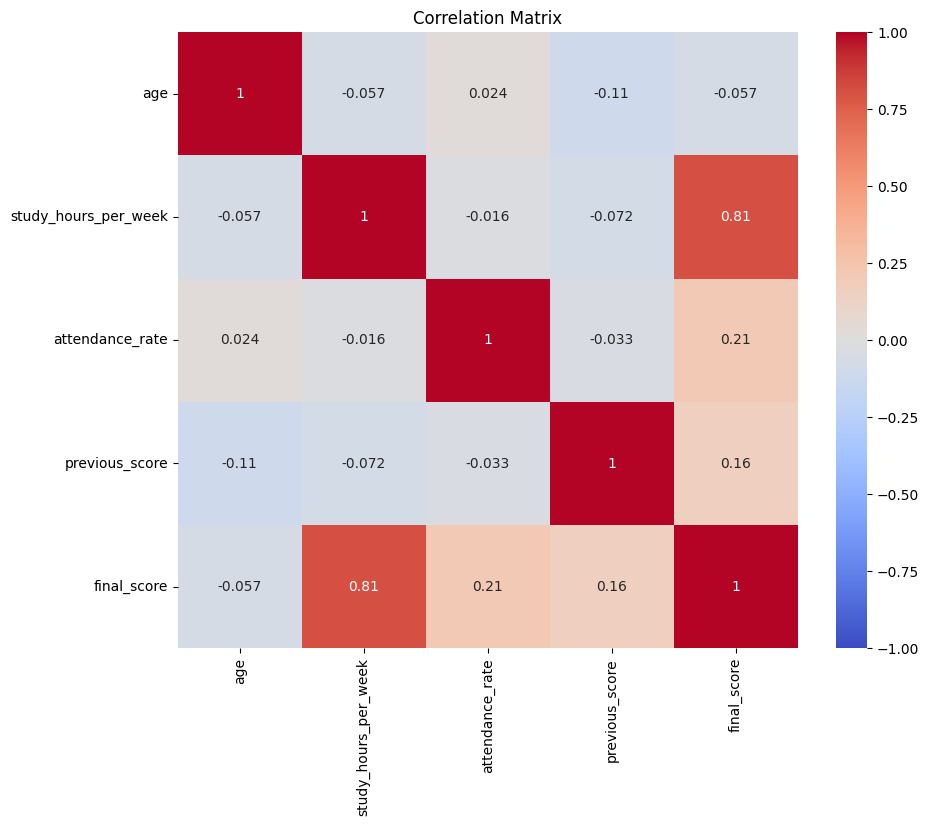

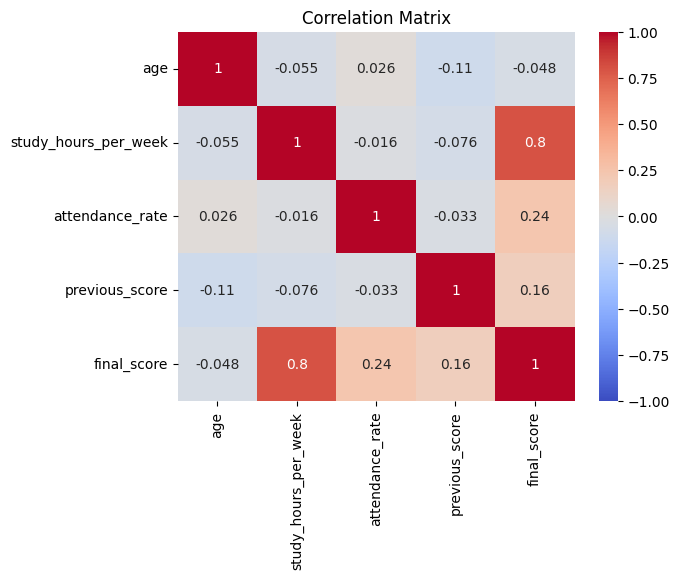

In [ ]:
correlation_matrix_spearman = df.corr(numeric_only=True, method="spearman")
correlation_matrix_pearson = df.corr(numeric_only=True, method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_spearman, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix (Spearman)')
plt.show()
sns.heatmap(correlation_matrix_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix (Pearson)')
plt.show()


Korelasi matriks kuat antara:
study_hours_per_week <=> final_score

Medium antara:
attendance_rate <=> attendance_rate
previous_score <=> final_score


## Analisa plot secara tiap variabel

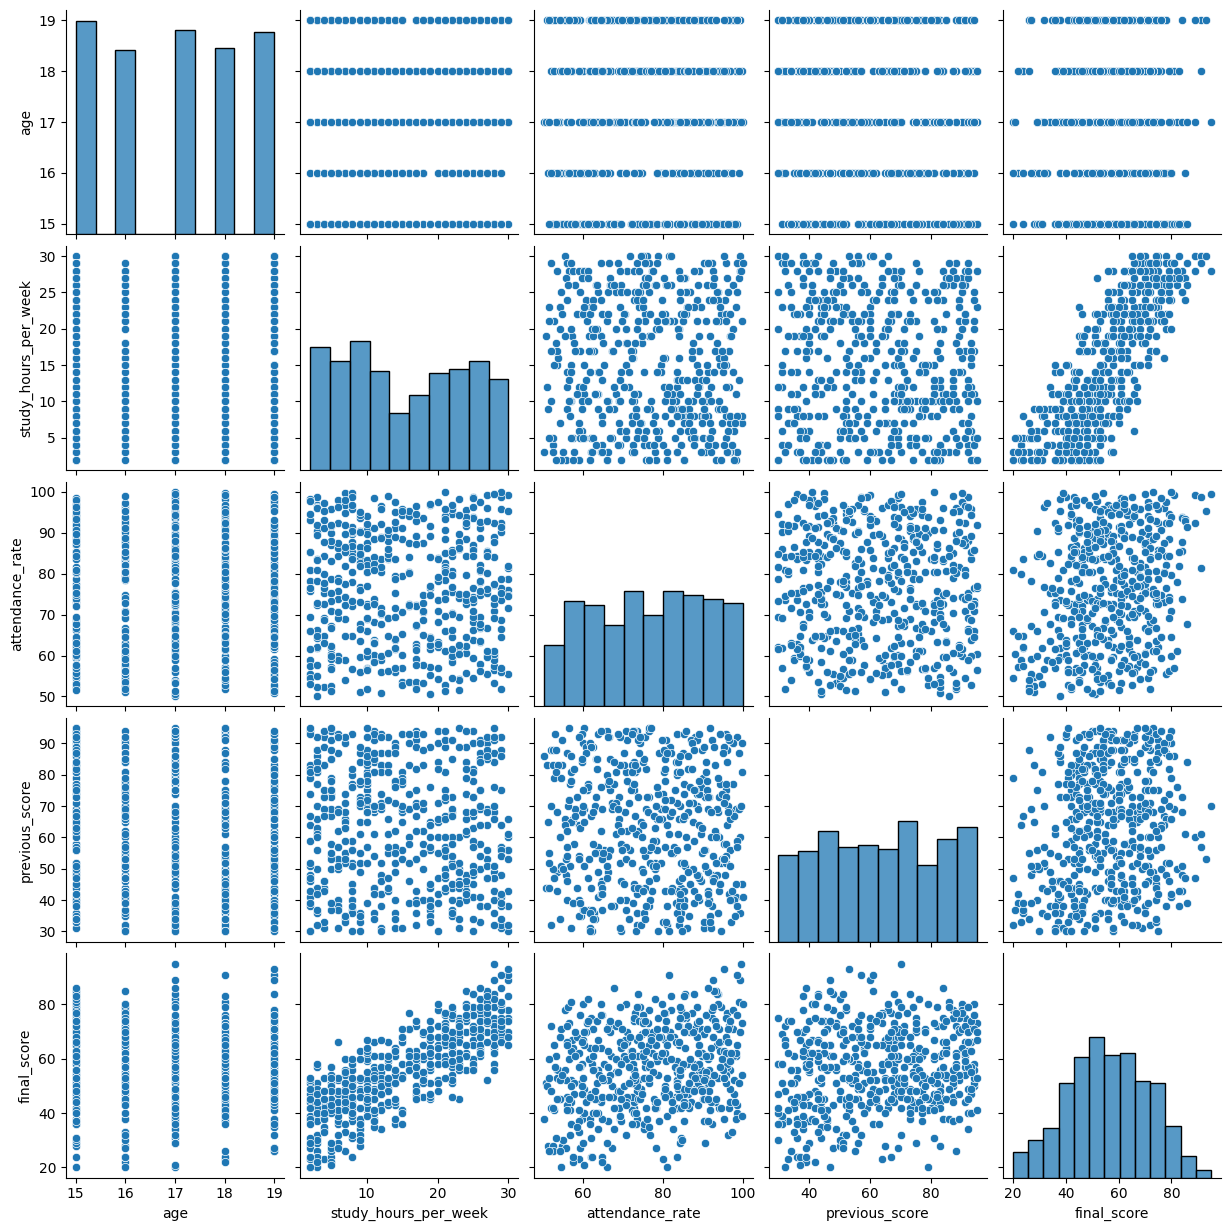

In [ ]:
sns.pairplot(df)

## Analisa Distribusi Data

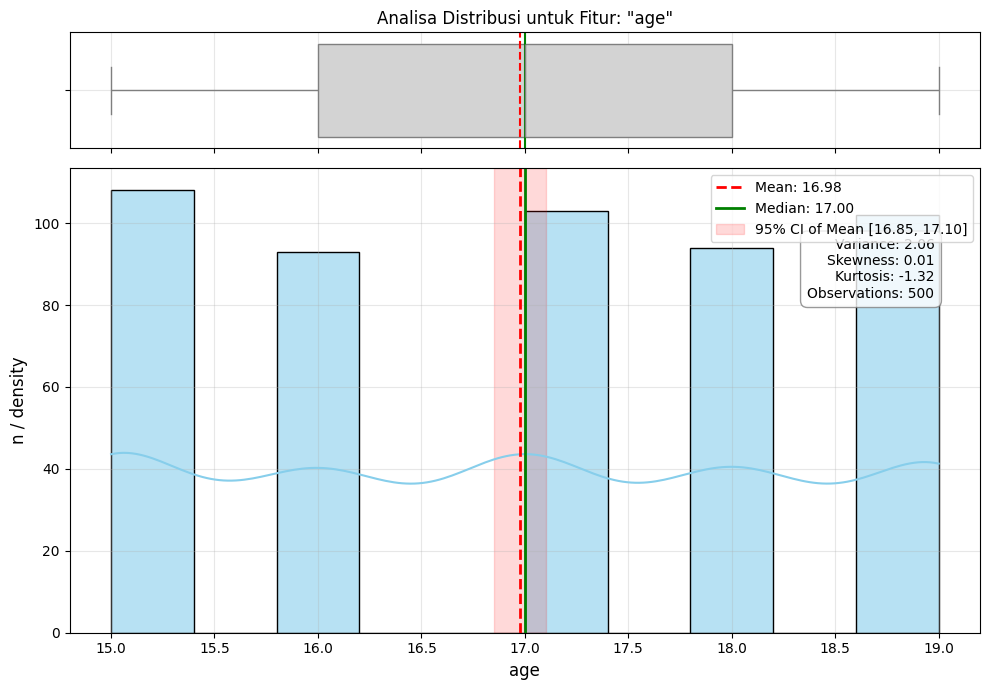

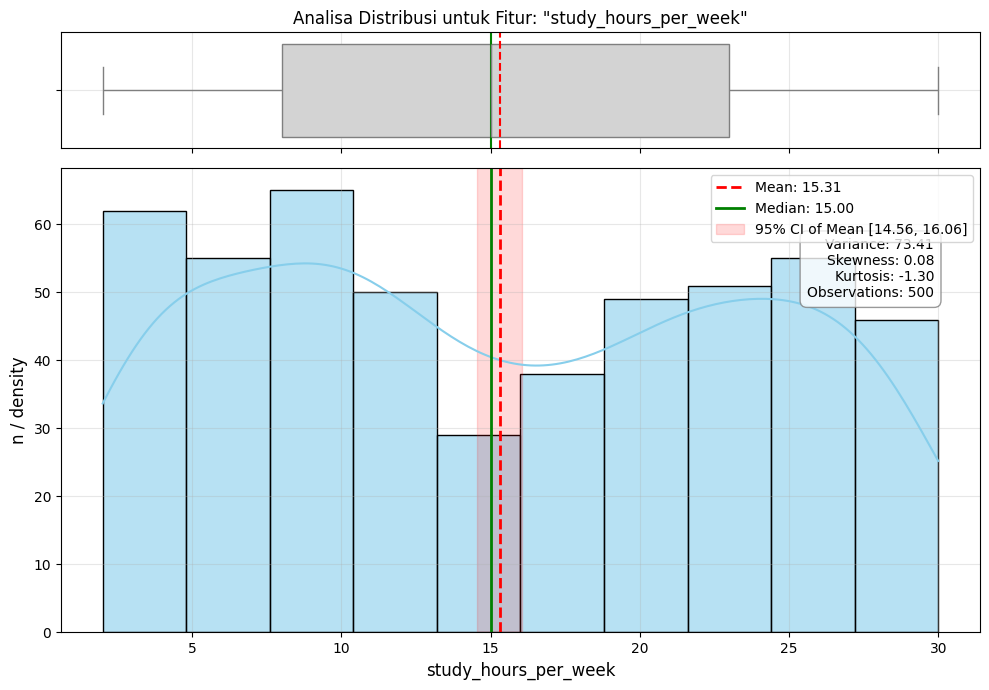

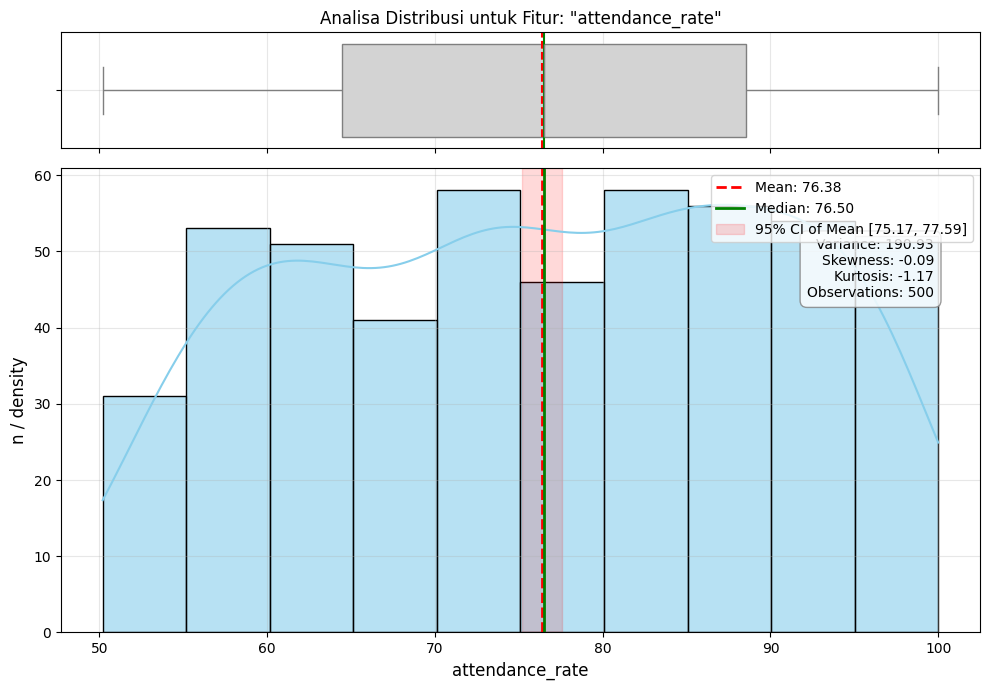

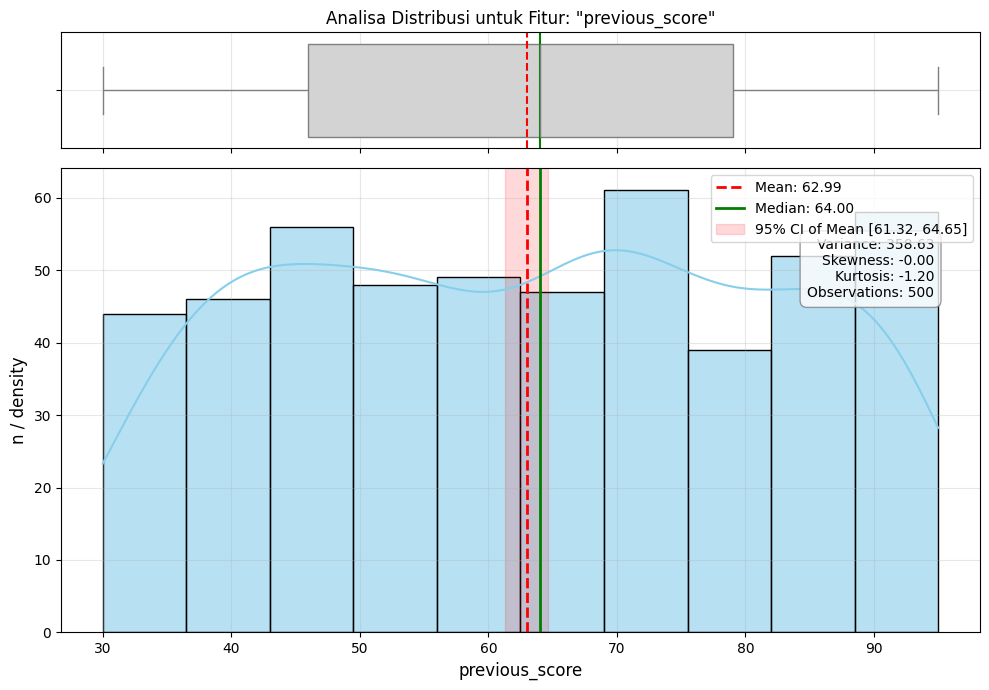

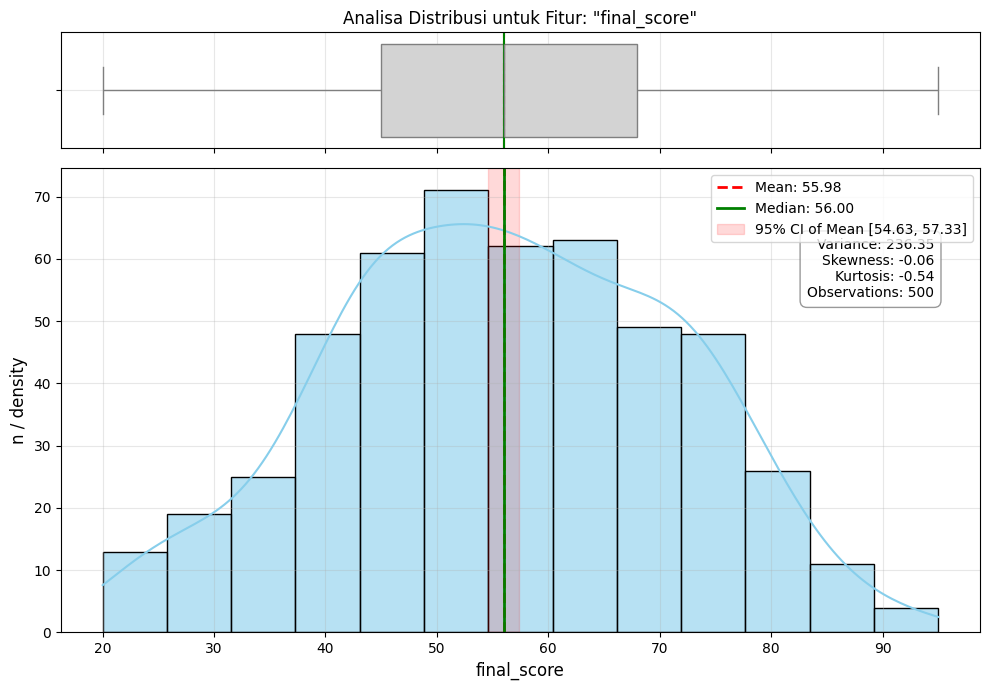

In [19]:
analisa_distribusi_fitur(df)